# Benchmarking Autoregressive Conditional Diffusion Models for Turbulent Flow Simulation

This notebook contains a simple example to train and evaluate autoregressive conditional diffusion models ([ACDM](https://github.com/tum-pbs/autoreg-pde-diffusion)), following our [paper](https://arxiv.org/abs/2309.01745). The problem setting is the creation of a diffusion-based architecture, that can probabilistically predict the next simulation step of a turbulent flow simulation.

As a first step, we download and extract a small toy dataset containing a sequence from the transonic flow data set $\texttt{Tra}$ with mach number $\textit{Ma} = 0.7$. Furthermore, a pre-trained model checkpoint is downloaded. This might take a few minutes. (Note: the commands will not re-download files, if already downloaded successfully)

In [1]:
# !wget -nc "https://dataserv.ub.tum.de/s/m1734798.001/download?path=/&files=128_tra_small.zip" -O data/128_tra_small.zip --no-check-certificate 
# !unzip -nq data/128_tra_small.zip -d data
# !wget -nc "https://dataserv.ub.tum.de/s/m1734798.001/download?path=/&files=checkpoints_acdm_tra.zip" -O models/checkpoints_acdm_tra.zip --no-check-certificate 
# !unzip -nq models/checkpoints_acdm_tra.zip -d models

Colab already comes with a range of pre-installed packages and we only need to additionally install the *einops* package. If you are running this file locally and not inside colab, follow the [installation instructions for ACDM](https://github.com/tum-pbs/autoreg-pde-diffusion) to install required packages before continuing instead.

In [2]:
# try:
#     import google.colab  # only to ensure that we are inside colab
#     !pip install einops
# except ImportError:
#     print("This notebook is running locally, please follow the ACDM installation instructions first, then continue with the cell below.")
#     pass

Lets import some packages that we will need in the follwing.

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, SequentialSampler, RandomSampler

from einops import rearrange
from functools import partial

import matplotlib.pyplot as plt
import logging
import copy
import numpy as np

import math
import os, json
from typing import List,Tuple,Dict

import sys

sys.path.append(os.path.abspath('../ai4flow/acdm'))

from turbpred.data_transformations import Transforms
from turbpred.model_diffusion import DiffusionModel
from turbpred.params import DataParams
from turbpred.model import PredictionModel
from turbpred.logger import Logger
from turbpred.params import DataParams, TrainingParams, LossParams, ModelParamsEncoder, ModelParamsDecoder, ModelParamsLatent
from turbpred.turbulence_dataset import TurbulenceDataset
from turbpred.data_transformations import Transforms
from turbpred.loss import PredictionLoss
from turbpred.loss_history import LossHistory
from turbpred.trainer_diffusion import TrainerDiffusion, TesterDiffusion


/home/chunyang/miniconda3/envs/ACDM/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data Handling and Loading

Next, we prepare a class to handle and load the downloaded data set, as well as a data transformations class to handle the data normalization. Mean and standard deviation values are precomputed constants for any given data set.

In [4]:

class TurbulenceDataset(Dataset):
    """Data set for turbulence and wavelet noise data

    Args:
        name: name of the dataset
        dataDirs: list of paths to data directories
        filterTop: filter for top level folder names (e.g. different types of data)
        excludeFilterTop: mode for filterTop (exclude or include)
        filterSim: filter simulations by min and max (min inclusive, max exclusive)
        excludefilterSim: mode for filterSim (exclude or include)
        filterFrame: mandatory filter for simulation frames by min and max (min inclusive, max exclusive)
        sequenceLength: number of frames to group into a sequence and number of frames to omit in between
        randSeqOffset: randomizes the starting frame of each sequence
        simFields: list of simulation fields to include (vel is always included) ["dens", "pres"]
        simParams: list of simulation parameters to include ["rey", "mach"]
        printLevel: print mode for contents of the dataset ["none", "top", "sim", "full"]
        logLevel: log mode for contents of the dataset ["none", "top", "sim", "full"]
    """
    transform: Transforms
    name:str
    dataDirs:List[str]
    filterTop:List[str]
    excludeFilterTop:bool
    filterSim:List[Tuple[int, int]]
    excludefilterSim:bool
    filterFrame:List[Tuple[int, int]]
    sequenceLength:List[Tuple[int, int]]
    randSeqOffset:bool
    simFields:List[str]
    simParams:List[str]
    printLevel:str="none"
    logLevel:str="sim"

    def __init__(self, name:str, dataDirs:List[str], filterTop:List[str], excludeFilterTop:bool=False, filterSim:List[Tuple[int, int]]=[],
                excludefilterSim:bool=False, filterFrame:List[Tuple[int, int]]=[], sequenceLength:List[Tuple[int, int]]=[],
                randSeqOffset:bool=False, simFields:List[str]=[], simParams:List[str]=[], printLevel:str="none", logLevel:str="sim"):

        assert (len(filterSim) in [0,1,len(filterTop)]), "Sim filter is not set up correctly. Use len=0 for all; len=1 for the same everywhere, len=len(filterTop) to adjust for each top filter"
        assert (len(filterFrame) in [1,len(filterTop)]), "Frame filter is not set up correctly. Use len=1 for the same everywhere, len=len(filterTop) to adjust for each top filter"
        assert (len(sequenceLength) == len(filterFrame)), "Sequence length is not set up correctly, it should match the frame filter."
        if excludeFilterTop:
            assert (len(filterSim) <= 1), "Excluded top filter and adjust sim filtering is not supported!"
            assert (len(filterFrame) <= 1), "Excluded top filter and adjust frame filtering is not supported!"
        assert (printLevel in ["none", "top", "sim", "full"]), "Invalid print level!"

        self.transform = None
        self.name = name
        self.dataDirs = dataDirs
        self.filterTop = filterTop
        self.excludeFilterTop = excludeFilterTop
        self.filterSim = filterSim
        self.excludefilterSim = excludefilterSim
        self.filterFrame = filterFrame
        self.sequenceLength = sequenceLength
        self.randSeqOffset = randSeqOffset
        self.simFields = ["velocity"]
        if "velZ" in simFields:
            self.simFields += ["velocityZ"]
        if "dens" in simFields:
            self.simFields += ["density"]
        if "pres" in simFields:
            self.simFields += ["pressure"]

        self.simParams = simParams
        self.printLevel = printLevel
        self.logLevel = logLevel

        self.summaryPrint = []
        self.summaryLog = []
        self.summaryPrint += ["Dataset " + name + " at " + str(dataDirs)]
        self.summaryLog   += ["Dataset " + name + " at " + str(dataDirs)]
        self.summaryPrint += [self.getFilterInfoString()]
        self.summaryLog   += [self.getFilterInfoString()]

        # BUILD FULL FILE LIST
        self.dataPaths = []
        self.dataPathModes = []

        for dataDir in dataDirs:
            topDirs = os.listdir(dataDir)
            topDirs.sort()

            # top level folders
            for topDir in topDirs:
                if filterTop:
                    # continue when excluding or including according to filter
                    if excludeFilterTop == any( item in topDir for item in filterTop ):
                        continue

                match = -1
                # compute matching top filter for according sim or frame filtering
                if len(filterSim) > 1 or len(filterFrame) > 1:
                    for i in range(len(filterTop)):
                        if filterTop[i] in topDir:
                            match = i
                            break
                    assert (match >= 0), "Match computation error"

                simDir = os.path.join(dataDir, topDir)
                sims = os.listdir(simDir)
                sims.sort()

                if printLevel == "top":
                    self.summaryPrint += ["Top folder loaded: " + simDir.replace(dataDir + "/", "")]
                if logLevel == "top":
                    self.summaryLog   += ["Top folder loaded: " + simDir.replace(dataDir + "/", "")]

                # sim_000001 folders
                for sim in sims:
                    currentDir = os.path.join(simDir, sim)
                    if not os.path.isdir(currentDir):
                        continue

                    if len(filterSim) > 0:
                        simNum = int(sim.split("_")[1])
                        if len(filterSim) == 1:
                            if type(filterSim[0]) is tuple:
                                inside = simNum >= filterSim[0][0] and simNum < filterSim[0][1]
                            elif type(filterSim[0]) is list:
                                inside = simNum in filterSim[0]
                        else:
                            if type(filterSim[match]) is tuple:
                                inside = simNum >= filterSim[match][0] and simNum < filterSim[match][1]
                            elif type(filterSim[match]) is list:
                                inside = simNum in filterSim[match]
                        # continue when excluding or including according to filter
                        if inside == excludefilterSim:
                            continue

                    if printLevel == "sim":
                        self.summaryPrint += ["Sim loaded: " + currentDir.replace(dataDir + "/", "")]
                    if logLevel == "sim":
                        self.summaryLog   += ["Sim loaded: " + currentDir.replace(dataDir + "/", "")]

                    # individual simulation frames
                    minFrame = filterFrame[0][0] if len(filterFrame) == 1 else filterFrame[match][0]
                    maxFrame = filterFrame[0][1] if len(filterFrame) == 1 else filterFrame[match][1]
                    seqLength = sequenceLength[0][0] if len(sequenceLength) == 1 else sequenceLength[match][0]
                    seqSkip   = sequenceLength[0][1] if len(sequenceLength) == 1 else sequenceLength[match][1]
                    for seqStart in range(minFrame, maxFrame, seqLength*seqSkip):
                        validSeq = True
                        for frame in range(seqStart, seqStart+seqLength*seqSkip, seqSkip):
                            # discard incomplete sequences at simulation end
                            if seqStart+seqLength*seqSkip > maxFrame:
                                validSeq = False
                                break

                            for field in self.simFields:
                                currentField = os.path.join(currentDir, "%s_%06d.npz" % (field, frame))
                                if not os.path.isfile(currentField):
                                    raise FileNotFoundError("Could not load %s file: %s" % (field, currentField))

                        # imcomplete sequence means there are no more frames left
                        if not validSeq:
                            break

                        if printLevel == "full":
                            self.summaryPrint += ["Frames %s loaded: %s/%s_%06d-%06d(%03d).npz" % ("-".join(self.simFields),
                                        currentDir.replace(dataDir + "/", ""), "-".join(self.simFields), seqStart, seqStart + seqLength*(seqSkip-1), seqSkip)]
                        if logLevel == "full":
                            self.summaryLog   += ["Frames %s loaded: %s/%s_%06d-%06d(%03d).npz" % ("-".join(self.simFields),
                                        currentDir.replace(dataDir + "/", ""), "-".join(self.simFields), seqStart, seqStart + seqLength*(seqSkip-1), seqSkip)]

                        self.dataPaths.append((currentDir, seqStart, seqStart + seqLength*seqSkip, seqSkip))

        self.summaryPrint += ["Dataset Length: %d\n" % len(self.dataPaths)]
        self.summaryLog   += ["Dataset Length: %d\n" % len(self.dataPaths)]


    def __len__(self) -> int:
        return len(self.dataPaths)


    def __getitem__(self, idx:int) -> dict:
        # sequence indexing
        basePath, seqStart, seqEnd, seqSkip = self.dataPaths[idx]
        seqLen = int((seqEnd - seqStart) / seqSkip)
        if self.randSeqOffset:
            halfSeq = int((seqEnd-seqStart) / 2)
            offset = torch.randint(-halfSeq, halfSeq+1, (1,)).item()
            if seqStart + offset >= self.filterFrame[0][0] and seqEnd + offset < self.filterFrame[0][1]:
                seqStart = seqStart + offset
                seqEnd = seqEnd + offset

        # loading simulation parameters
        with open(os.path.join(basePath, "src", "description.json")) as f:
            loadedJSON = json.load(f)

            loadNames = ["Reynolds Number", "Mach Number", "Drag Coefficient", "Lift Coefficient", "Z Slice"]
            loadedParams = {}
            for loadName in loadNames:
                loadedParam = np.zeros(seqLen, dtype=np.float32)
                if loadName in loadedJSON:
                    temp = loadedJSON[loadName]
                    if isinstance(temp, int) or isinstance(temp, float):
                        temp = np.array(temp, dtype=np.float32)
                        loadedParam[0:] = np.repeat(temp, seqLen)
                    elif isinstance(temp, list):
                        loadedParam[0:] = temp[seqStart:seqEnd:seqSkip]
                    else:
                        raise ValueError("Invalid simulation parameter data type")
                loadedParams[loadName] = loadedParam

            if "rey" in self.simParams and "mach" in self.simParams:
                simParameters = np.stack([loadedParams["Reynolds Number"], loadedParams["Mach Number"]], axis=1)
            elif "rey" in self.simParams:
                simParameters = np.reshape(loadedParams["Reynolds Number"], (-1,1))
            elif "mach" in self.simParams:
                simParameters = np.reshape(loadedParams["Mach Number"], (-1,1))
            elif "zslice" in self.simParams:
                simParameters = np.reshape(loadedParams["Z Slice"], (-1,1))
            elif not self.simParams:
                simParameters ={}
            else:
                raise ValueError("Invalid specification of simulation parameters")

        # loading obstacle mask
        if os.path.isfile(os.path.join(basePath, "obstacle_mask.npz")):
            obsMask = np.load(os.path.join(basePath, "obstacle_mask.npz"))['arr_0']
        else:
            obsMask = None

        # loading fields and combining them with simulation parameters
        loaded = {}
        for field in self.simFields:
            loaded[field] = []

        for frame in range(seqStart, seqEnd, seqSkip):
            for field in self.simFields:
                loadedArr = np.load(os.path.join(basePath, "%s_%06d.npz" % (field,frame)))['arr_0']
                loaded[field] += [loadedArr.astype(np.float32)]

        loadedFields = []
        for field in self.simFields:
            loadedFields += [np.stack(loaded[field], axis=0)]

        if type(simParameters) is not dict:
            vel = loadedFields[0]
            if vel.ndim == 4:
                simParExpanded = simParameters[:,:,np.newaxis,np.newaxis]
                simParExpanded = np.repeat(np.repeat(simParExpanded, vel.shape[2], axis=2), vel.shape[3], axis=3)
            elif vel.ndim == 5:
                simParExpanded = simParameters[:,:,np.newaxis,np.newaxis,np.newaxis]
                simParExpanded = np.repeat(np.repeat(np.repeat(simParExpanded, vel.shape[2], axis=2), vel.shape[3], axis=3), vel.shape[4], axis=4)
            else:
                raise ValueError("Invalid input shape when loading samples!")
            loadedFields += [simParExpanded]

        data = np.concatenate(loadedFields, axis=1) # ORDER (fields): velocity (x,y), velocity z / density, pressure, ORDER (params): rey, mach, zslice

        # output
        dataPath = "%s/%s_%06d-%06d(%03d).npz" % (basePath, "-".join(self.simFields), seqStart, seqEnd - seqSkip, seqSkip)
        sample = {"data" : data, "simParameters" : simParameters, "allParameters" : loadedParams, "path" : dataPath}
        if obsMask is not None:
            sample["obsMask"] = obsMask

        if self.transform:
            sample = self.transform(sample)
        else:
            print("WARNING: no data transformations are employed!")

        return sample


    def printDatasetInfo(self):
        if self.transform:
            s  = "%s - Data Augmentations: %s\n" % (self.name, len(self.transform.p_d.augmentations))
            s += "\tactivate augmentations: [%s]\n" % ", ".join(self.transform.p_d.augmentations)
            if self.transform.crop:
                s += "\tcrop settings: outputSize (%d, %d)\n" % (self.transform.outputSize[0], self.transform.outputSize[1])
            if self.transform.resize:
                s += "\tresize settings: outputSize (%d, %d)\n" % (self.transform.outputSize[0], self.transform.outputSize[1])

            self.summaryPrint += [s]
            self.summaryLog   += [s]

        print('\n'.join(self.summaryPrint))
        logging.info('\n'.join(self.summaryLog))

    def getFilterInfoString(self) -> str:
        s  = "%s - Data Filter Setup: \n" % (self.name)
        s += "\tdataDirs: %s\n" % (str(self.dataDirs))
        s += "\tfilterTop: %s  exlude: %s\n" % (str(self.filterTop), self.excludeFilterTop)
        s += "\tfilterSim: %s  exlude: %s\n" % (str(self.filterSim), self.excludefilterSim)
        s += "\tfilterFrame: %s\n" % (str(self.filterFrame))
        s += "\tsequenceLength: %s\n" % (str(self.sequenceLength))
        return s


In [5]:

class Transforms(object):
    p_d: DataParams

    def __init__(self, p_d:DataParams):

        assert all(aug in ["normalize", "flip", "crop", "resize"]
                        for aug in p_d.augmentations), "Invalid augmentation provided!"
        assert not ("crop" in p_d.augmentations and "resize" in p_d.augmentations
                        ), "Crop and resize augmentation not allowed at the same time!"
        assert (p_d.normalizeMode != ""), "Invalid normalization mode!"

        self.p_d = p_d
        self.normalize = "normalize" in p_d.augmentations
        self.flip = "flip" in p_d.augmentations
        self.crop = "crop" in p_d.augmentations
        self.resize = "resize" in p_d.augmentations
        self.outputSize = p_d.dataSize
        self.dim = p_d.dimension
        self.simFields = p_d.simFields
        self.simParams = p_d.simParams

        # mean and std statistics from whole dataset for normalization
        if self.dim == 2:
            l = self.p_d.normalizeMode.lower()
            # if "inc" in l and "mixed" in l:
            if ("karman" in l or "inc" in l) and "mixed" in l:
                # ORDER (fields): velocity (x,y), --, pressure, ORDER (params): rey, --, --
                self.normMean = np.array([0.444969, 0.000299, 0, 0.000586, 550.000000, 0, 0], dtype=np.float32)
                self.normStd =  np.array([0.206128, 0.206128, 1, 0.003942, 262.678467, 1, 1], dtype=np.float32)

            # if "tra" in l and "mixed" in l:
            if ("mach" in l or "tra" in l) and "mixed" in l:
                # ORDER (fields): velocity (x,y), density, pressure, ORDER (params): rey, mach, --
                self.normMean = np.array([0.560642, -0.000129, 0.903352, 0.637941, 10000.000000, 0.700000, 0], dtype=np.float32)
                self.normStd =  np.array([0.216987, 0.216987, 0.145391, 0.119944, 1, 0.118322, 1], dtype=np.float32)

            if "iso" in l and "single" in l:
                # ORDER (fields): velocity (x,y,z), pressure, ORDER (params): --, --, --
                self.normMean = np.array([-0.054618, -0.385225, -0.255757, 0.033446, 0, 0, 0], dtype=np.float32)
                self.normStd =  np.array([0.539194, 0.710318, 0.510352, 0.258235, 1, 1, 1], dtype=np.float32)

        # seeding once for single thread data loading
        self.randGen = np.random.RandomState(torch.random.initial_seed() % 4294967295)


    def __call__(self, sample:dict):
        # seeding in every call for multi thread data loading
        if torch.utils.data.get_worker_info():
            self.randGen = np.random.RandomState(torch.utils.data.get_worker_info().seed % 4294967295)

        data = sample["data"]
        simParameters = sample["simParameters"]
        allParameters = sample["allParameters"]
        obsMask = sample.get("obsMask", None)
        path = sample["path"]

        # normalization to std. normal distr. with zero mean and unit std via statistics from whole dataset
        # ORDER (fields): velocity (x,y), velocity z / density, pressure, ORDER (params): rey, mach, zslice
        if self.normalize:
            filterList = [0, 1] if self.dim == 2 else [0, 1, 2]
            if "dens" in self.simFields or "velZ" in self.simFields:
                filterList += [2] if self.dim == 2 else [3]
            if "pres" in self.simFields:
                filterList += [3] if self.dim == 2 else [4]
            if "rey" in self.simParams:
                filterList += [4] if self.dim == 2 else [5]
            if "mach" in self.simParams:
                filterList += [5] if self.dim == 2 else [6]
            if "zslice" in self.simParams:
                filterList += [6] if self.dim == 2 else [7]
            filterArr = np.array(filterList)
            filterArrParam = filterArr[-len(self.simParams):]

            if self.simParams:
                meanParam = self.normMean[filterArrParam].reshape((1,-1))
                stdParam = self.normStd[filterArrParam].reshape((1,-1))
                simParameters = (simParameters - meanParam) / stdParam

            meanData = self.normMean[filterArr].reshape((1,-1,1,1)) if self.dim == 2 else self.normMean[filterArr].reshape((1,-1,1,1,1))
            stdData = self.normStd[filterArr].reshape((1,-1,1,1)) if self.dim == 2 else self.normStd[filterArr].reshape((1,-1,1,1,1))
            if self.dim == 2:
                data = (data - meanData) / stdData
            elif self.dim == 3:
                data = (data - meanData) / stdData

        # random flip
        if self.flip:
            if self.dim == 2:
                rand = self.randGen.rand(2) > 0.5
                flipped = False
                if rand[0]:
                    data = np.flip(data, axis=2)
                    flipped = True
                if rand[1]:
                    data = np.flip(data, axis=3)
                    flipped = True
                if flipped:
                    data = data.copy() #prevent negative strides that has issues with torch tensor creation
            if self.dim == 3:
                raise NotImplementedError("Flip augmentation not supported for 3D yet!")

        # random crop
        if self.crop:
            if self.dim == 2:
                s = self.outputSize
                if data.shape[2] > s[0] or data.shape[3] > s[1]:
                    c1 = self.randGen.randint(0, data.shape[2] - s[0]+1)
                    c2 = self.randGen.randint(0, data.shape[3] - s[1]+1)
                    data = data[..., c1:c1+s[0], c2:c2+s[1]]
            if self.dim == 3:
                raise NotImplementedError("Crop augmentation not supported for 3D yet!")

        # toTensor
        result = torch.from_numpy(data)
        if obsMask is not None:
            obsMask = torch.from_numpy(obsMask)

        # resize
        if self.resize:
            result = F.interpolate(result, self.outputSize, mode="bilinear", align_corners=True)
            if obsMask is not None:
                obsMask = F.interpolate(obsMask, self.outputSize, mode="nearest", align_corners=True)

        outDict = {"data": result, "simParameters": simParameters, "allParameters": allParameters, "path": path}
        if obsMask is not None:
            outDict["obsMask"] = obsMask
        return outDict

## Training

With all these building blocks out of the way, now its time put them together and train the diffusion model. You can choose to either continue training for a few epochs from the provided model checkpoint (takes less than a minute for 10 epochs), or train the model from scratch on the small examplary data set (takes about half an hour for 1000 epochs). Note that the prediction quality and diversity for training the model from scratch will be noticeably worse, due to limited amount of data available here.

Feel free to skip this step entirely, if you don't want to train the network. You can directly continue with the sampling below, by using the pre-trained checkpoint.

IndexError: list index out of range

In [7]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"
print("Training device: %s" % device)

p_d = DataParams(batch=64, augmentations=["normalize"], sequenceLength=[3,2], randSeqOffset=True,
            dataSize=[128,64], dimension=2, simFields=["pres"], simParams=["rey"], normalizeMode="incMixed")

trainSet = TurbulenceDataset("Training", ["/home/chunyang/projects/ACDM4SCIENCE/data/128_inc"], filterTop=["128_inc"], filterSim=[(10,81)], filterFrame=[(800,1300)],
                sequenceLength=[p_d.sequenceLength], randSeqOffset=p_d.randSeqOffset, simFields=p_d.simFields, simParams=p_d.simParams, printLevel="sim")


transTrain = Transforms(p_d)
trainSet.transform = transTrain

trainSet.printDatasetInfo()
trainSampler = RandomSampler(trainSet)
#trainSampler = SequentialSampler(trainSet)
trainLoader = DataLoader(trainSet, sampler=trainSampler,
                    batch_size=p_d.batch, drop_last=True, num_workers=4)


Training device: cuda:0
Dataset Training at ['/home/chunyang/projects/ACDM4SCIENCE/data/128_inc']
Training - Data Filter Setup: 
	dataDirs: ['/home/chunyang/projects/ACDM4SCIENCE/data/128_inc']
	filterTop: ['128_inc']  exlude: False
	filterSim: [(10, 81)]  exlude: False
	filterFrame: [(800, 1300)]
	sequenceLength: [[3, 2]]

Dataset Length: 0

Training - Data Augmentations: 1
	activate augmentations: [normalize]



ValueError: num_samples should be a positive integer value, but got num_samples=0

In [5]:
trainSet[1]["data"].shape

torch.Size([3, 4, 128, 64])

In [6]:
trainSet[1].keys()

dict_keys(['data', 'simParameters', 'allParameters', 'path', 'obsMask'])

In [9]:
trainSet[1]["simParameters"]

array([[1.3324275],
       [1.3324275],
       [1.3324275]], dtype=float32)

In [10]:
trainSet[1]["allParameters"]

{'Reynolds Number': array([900., 900., 900.], dtype=float32),
 'Mach Number': array([0., 0., 0.], dtype=float32),
 'Drag Coefficient': array([0., 0., 0.], dtype=float32),
 'Lift Coefficient': array([0., 0., 0.], dtype=float32),
 'Z Slice': array([0., 0., 0.], dtype=float32)}

In [11]:
trainSet[1]["path"]

'data/128_inc/sim_000010/velocity-pressure_000807-000811(002).npz'

In [12]:
trainSet[1]["obsMask"].shape

torch.Size([128, 64])

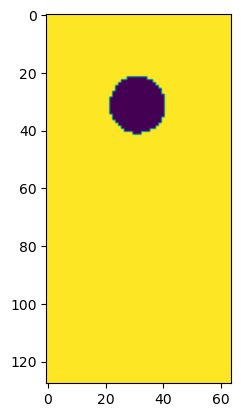

In [13]:
plt.imshow(trainSet[1]["obsMask"])

seq:  0


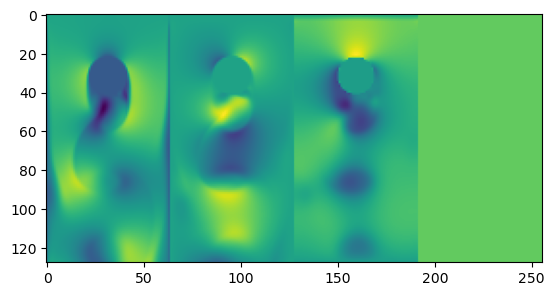

seq:  1


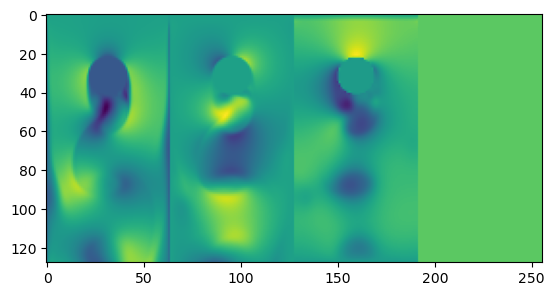

seq:  2


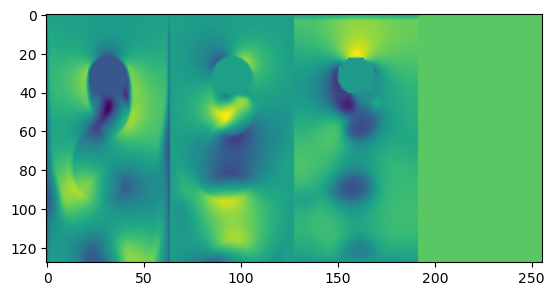

tensor([[1.3324, 1.3324, 1.3324,  ..., 1.3324, 1.3324, 1.3324],
        [1.3324, 1.3324, 1.3324,  ..., 1.3324, 1.3324, 1.3324],
        [1.3324, 1.3324, 1.3324,  ..., 1.3324, 1.3324, 1.3324],
        ...,
        [1.3324, 1.3324, 1.3324,  ..., 1.3324, 1.3324, 1.3324],
        [1.3324, 1.3324, 1.3324,  ..., 1.3324, 1.3324, 1.3324],
        [1.3324, 1.3324, 1.3324,  ..., 1.3324, 1.3324, 1.3324]])


In [14]:
idx = 20
d = trainSet[idx]["data"]

for i in range(d.shape[0]):
    print("seq: ", i)
    plt.imshow(rearrange(d[i], "c h w -> h (c w)"))
    plt.show()

torch.allclose(d[0, -1, :, :], torch.tensor(0.))
print(d[0, -1, :, :])

In [15]:
!pwd

/data_sdc/wcy/autoreg-pde-diffusion


In [16]:
startFromCheckpoint = True
useGPU = True
gpuID = "3"
os.environ["CUDA_VISIBLE_DEVICES"] = gpuID

pretrainPath = "/home/chunyang/projects/autoreg-pde-diffusion/models/models_inc/128_acdm-r20_00/Model.pth"

p_l = LossParams()
p_me = None
p_md = ModelParamsDecoder(arch="direct-ddpm+Prev", diffSteps=20, diffSchedule="linear", diffCondIntegration="noisy", trainingNoise=0.0)
p_ml = None
if startFromCheckpoint:
    p_t = TrainingParams(epochs=3, lr=0.001)
else:
    p_t = TrainingParams(epochs=3100, lr=0.0001)

model = PredictionModel(p_d, p_t, p_l, p_me, p_md, p_ml,
                        pretrainPath="" if not startFromCheckpoint else pretrainPath,
                        useGPU=useGPU)
model.printModelInfo()

Weights Trainable (All): 6981300 (6981300)      Dec: 6981300 (6981300)   
PredictionModel(
  (modelDecoder): DiffusionModel(
    (unet): Unet(
      (init_conv): Conv2d(12, 84, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
      (time_mlp): Sequential(
        (0): SinusoidalPositionEmbeddings()
        (1): Linear(in_features=128, out_features=512, bias=True)
        (2): GELU()
        (3): Linear(in_features=512, out_features=512, bias=True)
      )
      (downs): ModuleList(
        (0): ModuleList(
          (0): ConvNextBlock(
            (mlp): Sequential(
              (0): GELU()
              (1): Linear(in_features=512, out_features=84, bias=True)
            )
            (ds_conv): Conv2d(84, 84, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=84)
            (net): Sequential(
              (0): GroupNorm(1, 84, eps=1e-05, affine=True)
              (1): Conv2d(84, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
              (2): GELU()
           

In [17]:
# optimizer = torch.optim.Adam(model.parameters(), lr=p_t.lr, weight_decay=p_t.weightDecay)
# logger = Logger("ACDM", addNumber=True)
# logger.setup(model, optimizer)
# trainHistory = LossHistory("_train", "Training", logger.tfWriter, len(trainLoader),
#                                     0, 1, printInterval=1, logInterval=1, simFields=p_d.simFields)


# trainer = TrainerDiffusion(model, trainLoader, optimizer, trainHistory, logger.tfWriter, p_t)

# print('Starting Training')
# logger.saveTrainState(0)


# for epoch in range(0, p_t.epochs):
#     trainer.trainingStep(epoch)
#     logger.saveTrainState(epoch)

#     trainHistory.updateAccuracy([p_d,p_t,p_l,p_me,p_md,p_ml], [], epoch==p_t.epochs-1)


## Inference

We can now sample the trained diffusion model to create probabilistic predictions for a test set of flow trajectories. Here, we only use two sequences of 60 steps from the $\textit{Ma}=0.7$ data set, at a different physical time than the training data above. We store both predictions and ground truth in tensors with shape $(samples \times sequences \times sequenceLength \times channels \times sizeX \times sizeY)$, that are used for the visualization below.

In [18]:
# get: 1. testSet, testTransformer, testSampler and testLoader.
dataTransformationFieldIndices = [0,1,3,4]

testSet = TurbulenceDataset("Test Low Reynolds 100-200", ["data"], filterTop=["128_inc"], filterSim=[[0, 82,84,86,88,90]],
                filterFrame=[(1000,1150)], sequenceLength=[[60,2]], simFields=["pres"], simParams=["rey"], printLevel="sim")
p_d_test = copy.deepcopy(model.p_d)
p_d_test.augmentations = ["normalize"]
p_d_test.sequenceLength = testSet.sequenceLength
p_d_test.randSeqOffset = False

testTransformations = Transforms(p_d_test)

testSet.transform = testTransformations
testSampler = SequentialSampler(testSet)
testLoader = DataLoader(testSet, sampler=testSampler, batch_size=len(testSet), drop_last=False)


In [19]:
testSet[1].keys()

dict_keys(['data', 'simParameters', 'allParameters', 'path', 'obsMask'])

In [20]:
# input sequence visulisation:

# idx = 0
# d = testSet[idx]["data"]

# for i in range(d.shape[0]):
#     print("seq: ", i)
#     plt.imshow(rearrange(d[i], "c h w -> h (c w)"))
#     plt.show()

# # torch.allclose(d[0, -1, :, :], torch.tensor(0.))
# print(d[0, -1, :, :])

In [63]:
# sample for dataset and model inference
model = PredictionModel.load("/home/chunyang/projects/autoreg-pde-diffusion/models/models_inc/128_acdm-r20_00/Model.pth", useGPU=True)
model.eval()
model.to(device)

evalOptions = {"numEvals": 1,
    "sequentialEvalRuns": {"lowRey": True, "highRey": True, "varReyIn": True},
    "samplingMode": "ddpm",
    "posteriorSampling": "random",
    "initialSampling": "random",
    "conditioningIntegration": "noisy"
},

if isinstance(model.modelDecoder, DiffusionModel):
    if "samplingMode" in evalOptions:
        model.modelDecoder.inferenceSamplingMode = evalOptions["samplingMode"]
    if "posteriorSampling" in evalOptions:
        model.modelDecoder.inferencePosteriorSampling = evalOptions["posteriorSampling"]
    if "initialSampling" in evalOptions:
        model.modelDecoder.inferenceInitialSampling = evalOptions["initialSampling"]
    if "conditioningIntegration" in evalOptions:
        model.modelDecoder.inferenceConditioningIntegration = evalOptions["conditioningIntegration"]

elif isinstance(model.modelDecoder, torch.nn.ModuleList):
    for module in model.modelDecoder:
        if isinstance(module, DiffusionModel):
            if "samplingMode" in evalOptions:
                module.inferenceSamplingMode = evalOptions["samplingMode"]
            if "posteriorSampling" in evalOptions:
                module.inferencePosteriorSampling = evalOptions["posteriorSampling"]
            if "initialSampling" in evalOptions:
                module.inferenceInitialSampling = evalOptions["initialSampling"]
            if "conditioningIntegration" in evalOptions:
                module.inferenceConditioningIntegration = evalOptions["conditioningIntegration"]

numSamples = 5

with torch.no_grad():
    predSamples = []
    for s, sample in enumerate(testLoader, 0):
        data = sample["data"].to(device)
        simParameters = sample["simParameters"].to(device) if type(sample["simParameters"]) is not dict else None
        prediction, _, _ = model(data, simParameters)
        print("prediction shape before double unsqueeze: ", prediction.shape)
        prediction = prediction.unsqueeze(0).unsqueeze(0)
        print("prediction shape after double unsqueeze: ", prediction.shape)
        predSamples += [prediction.cpu().numpy()]

    predSamples = np.concatenate(predSamples, axis=2)
    # normMean = testTransformations.normMean[dataTransformationFieldIndices]
    # normStd = testTransformations.normStd[dataTransformationFieldIndices]
    # normMean = np.expand_dims(normMean, axis=(0,1,2,3,5,6))
    # normStd = np.expand_dims(normStd, axis=(0,1,2,3,5,6))
    # predSamples = (predSamples * normStd) + normMean
    print("sampling finished")


Loading model from /home/chunyang/projects/autoreg-pde-diffusion/models/models_inc/128_acdm-r20_00/Model.pth
prediction shape before double unsqueeze:  torch.Size([6, 60, 4, 128, 64])
prediction shape after double unsqueeze:  torch.Size([1, 1, 6, 60, 4, 128, 64])
sampling finished


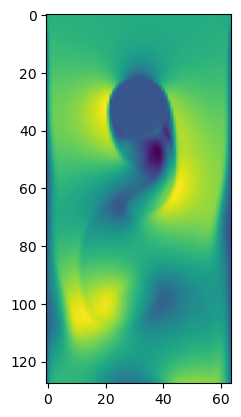

In [64]:
idx = 24
plt.imshow(predSamples[0][0, 0, idx, 0, :, :])

## Prediction Visualizations

After the sampling, we can analyze the ground truth flow trajectory and the samples generated by ACDM. Let's start with a direct visualization of the predictions.

In [65]:
print(predSamples[0].shape)

(1, 6, 60, 4, 128, 64)


-3.9071736 2.4590178
-3.9071736 3.0024724


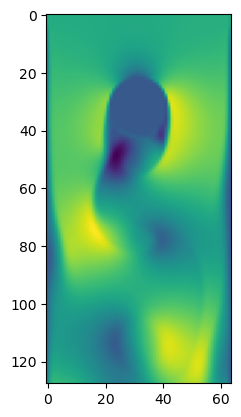

In [66]:
data = predSamples[0][0, 0, i, 0, :, :]
plt.imshow(data)
print(np.min(data), np.max(data))
data_expand = rearrange(predSamples[0][0, 0, i, :, :, :], 'c h w -> h (c w)')
print(np.min(data_expand), np.max(data_expand))

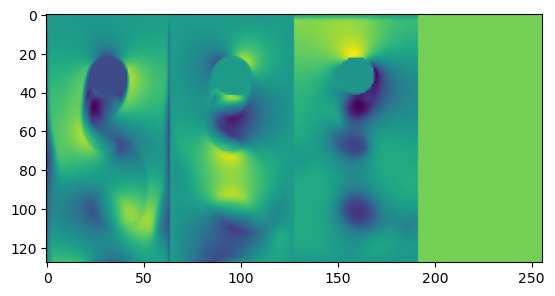

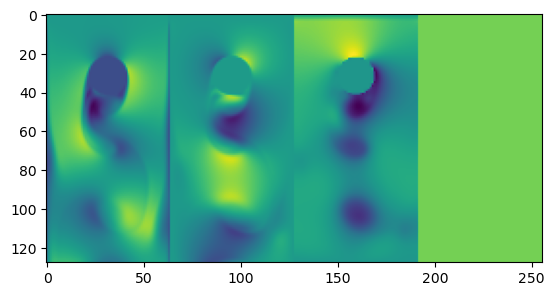

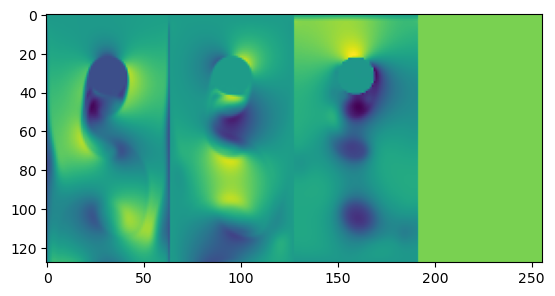

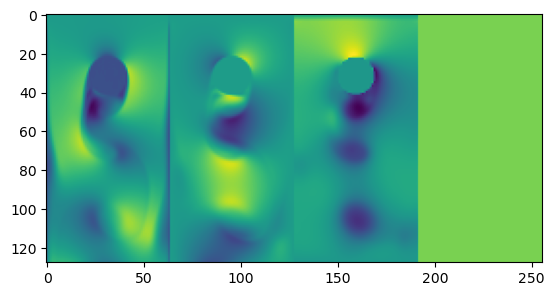

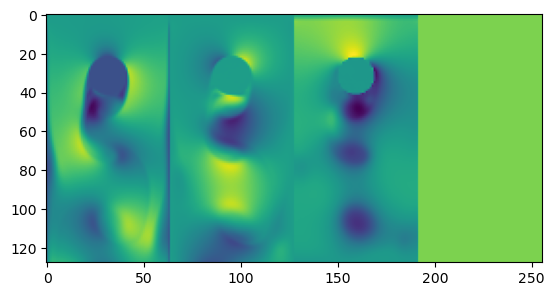

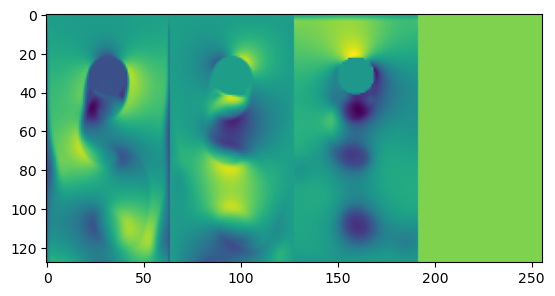

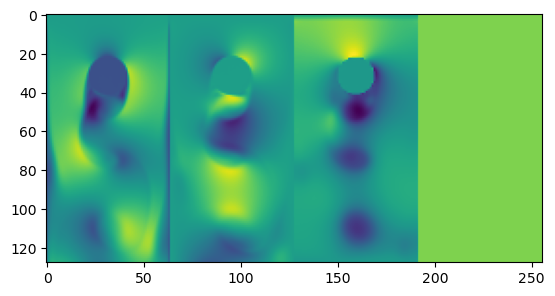

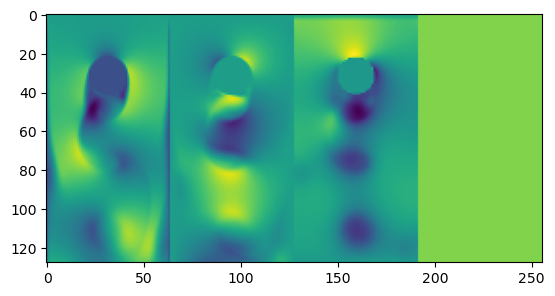

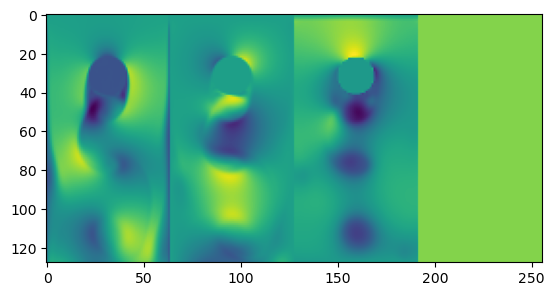

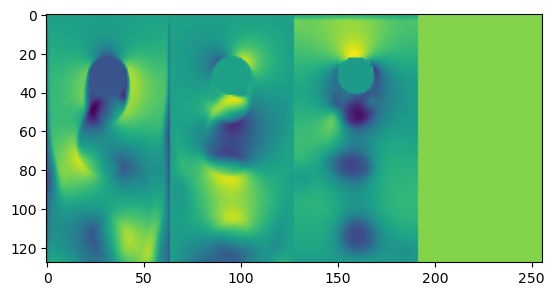

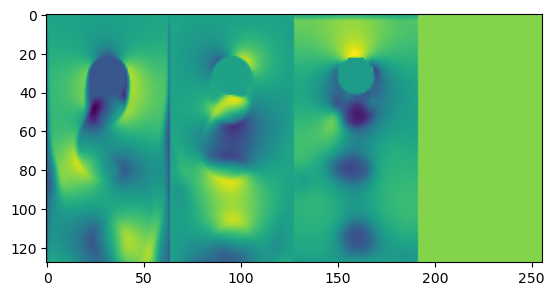

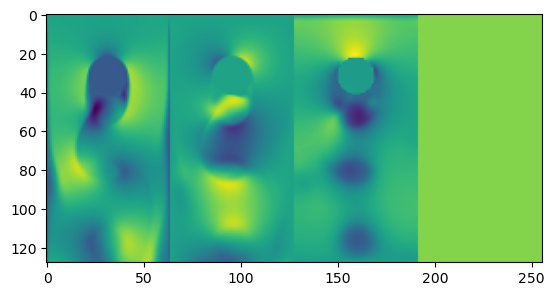

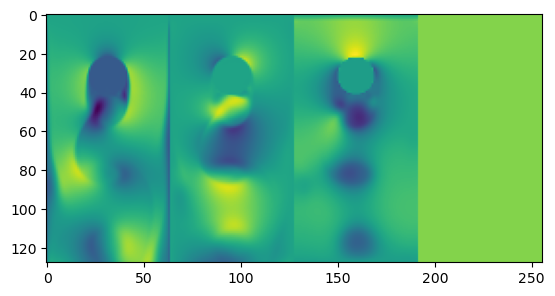

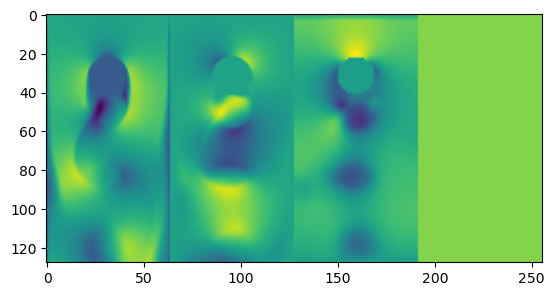

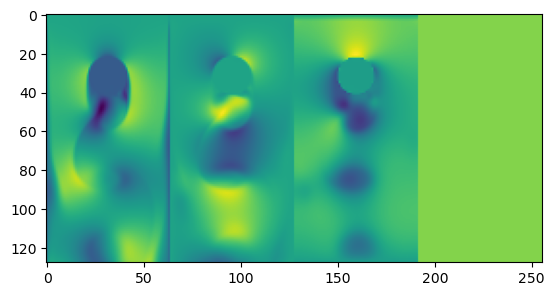

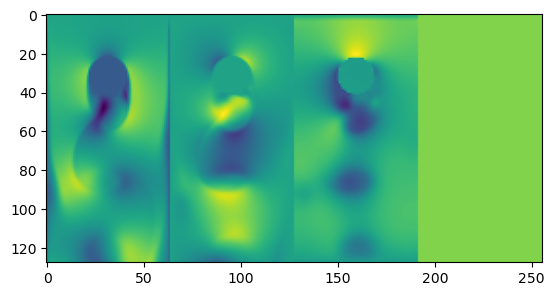

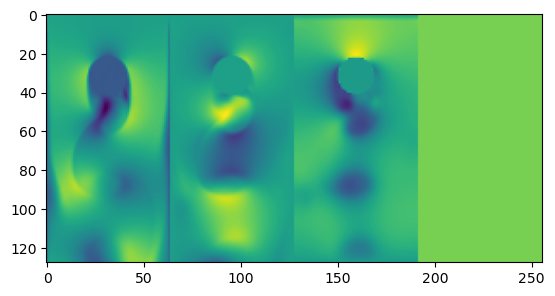

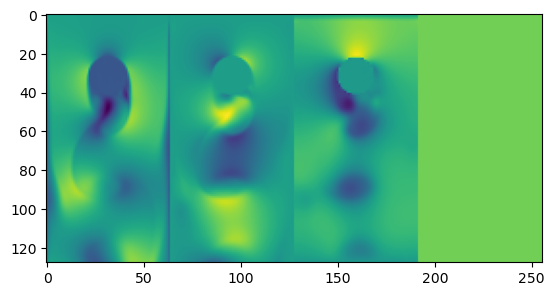

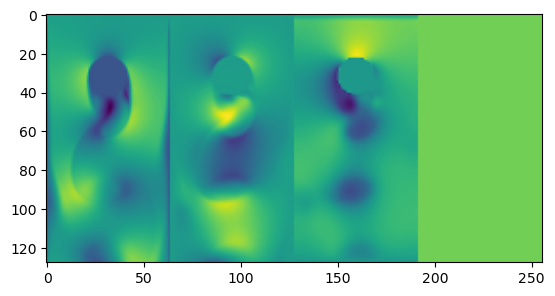

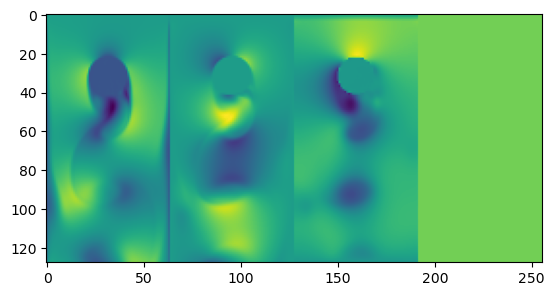

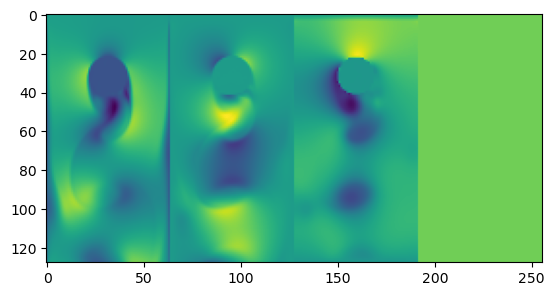

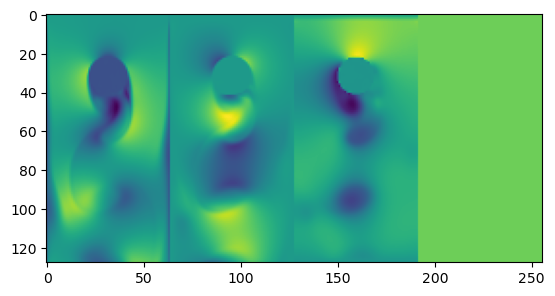

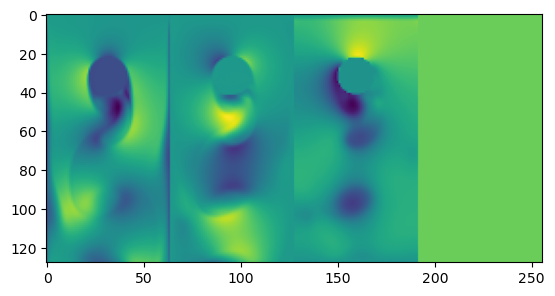

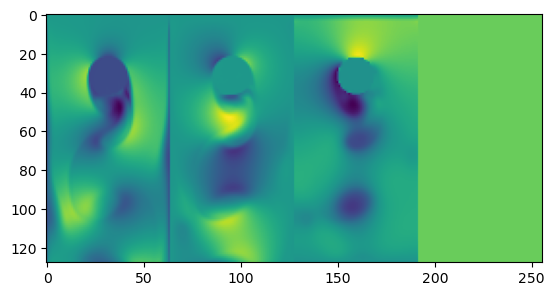

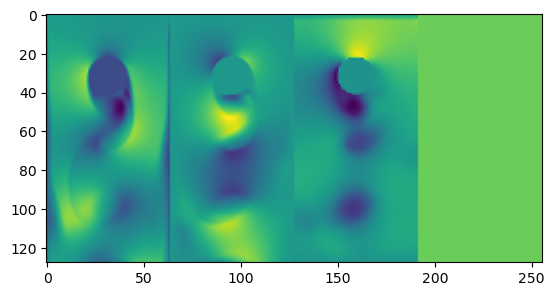

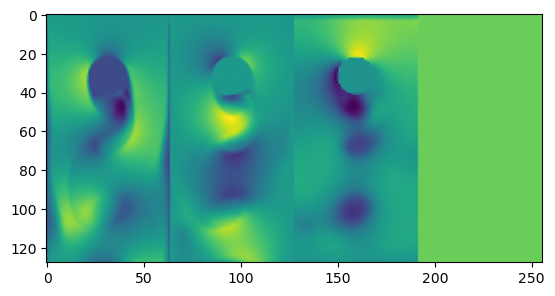

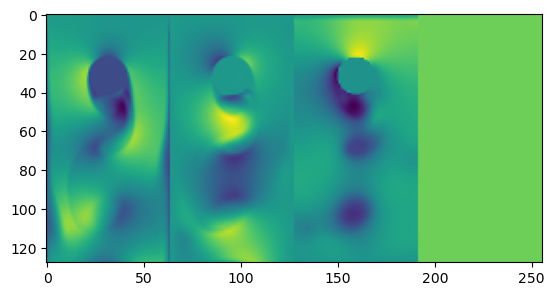

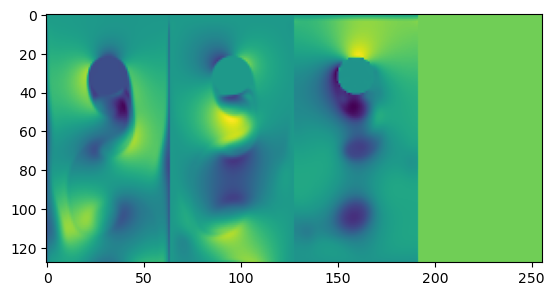

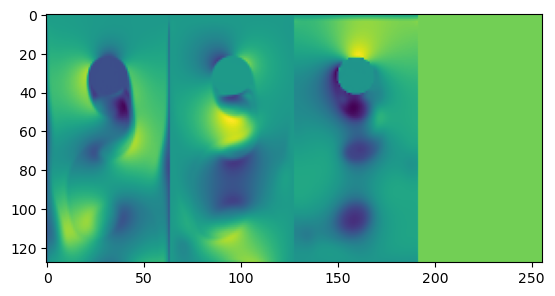

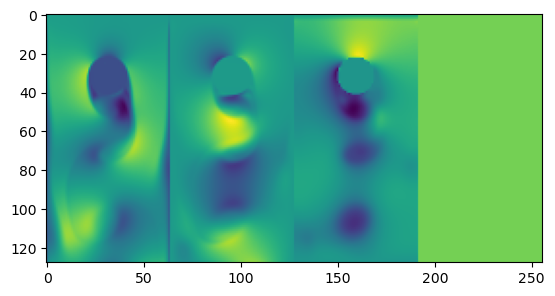

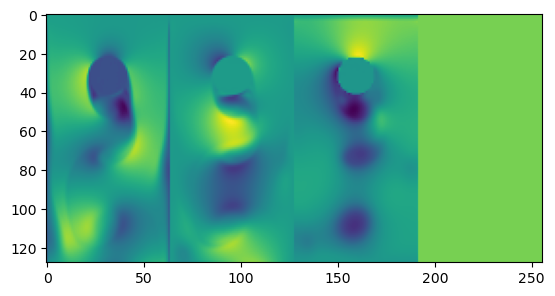

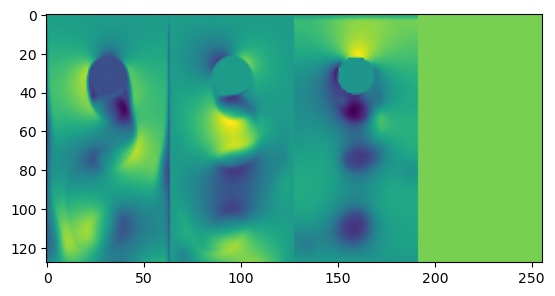

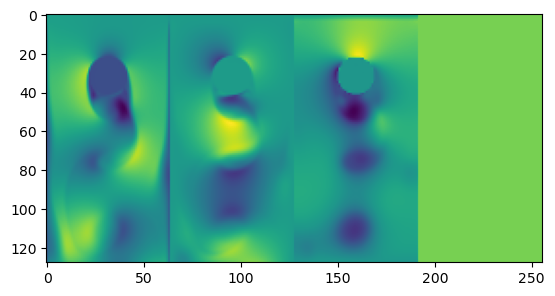

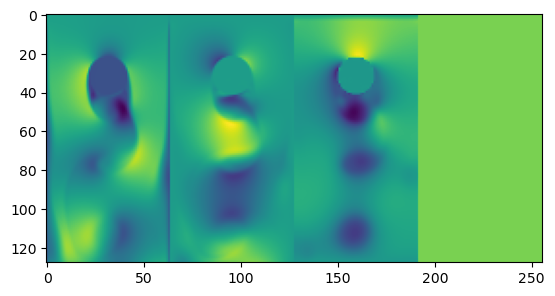

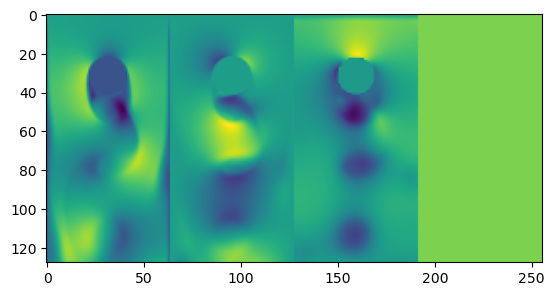

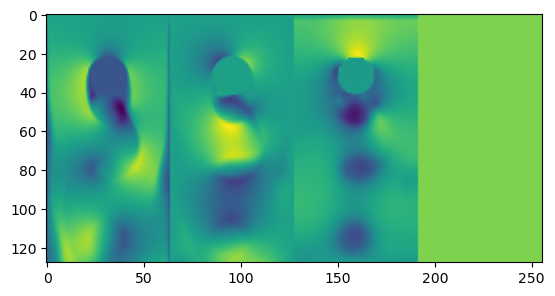

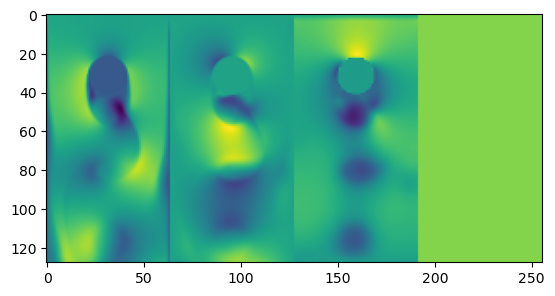

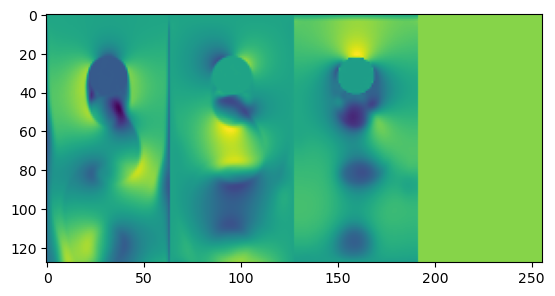

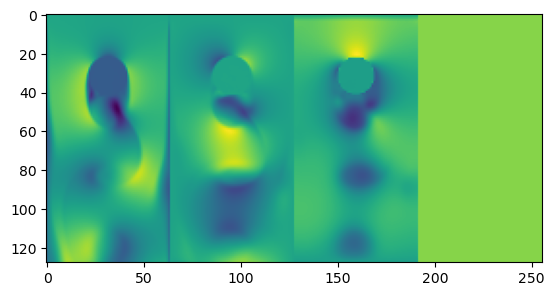

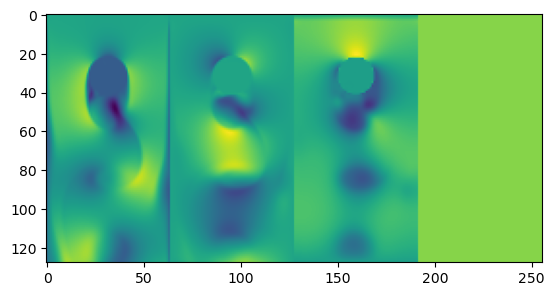

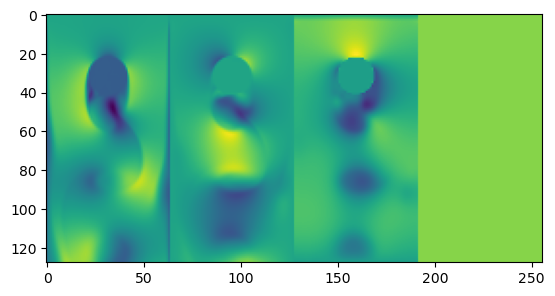

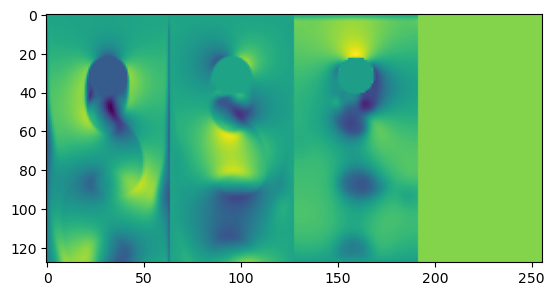

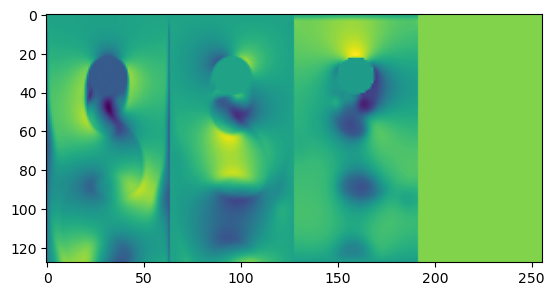

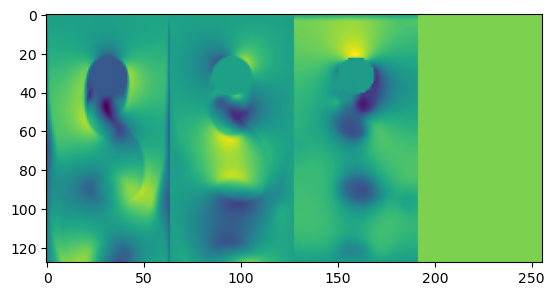

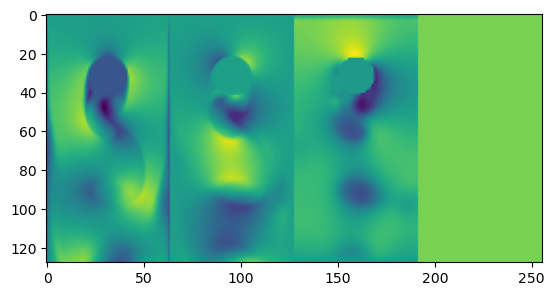

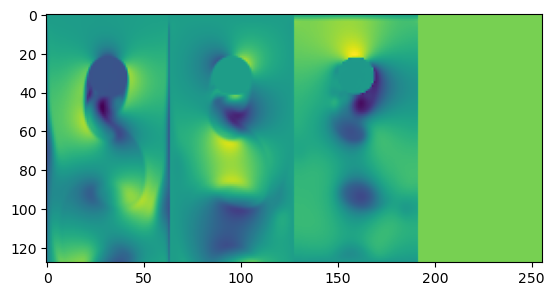

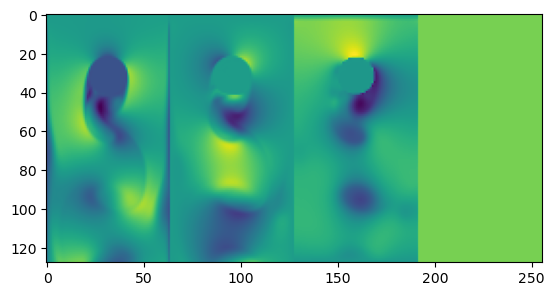

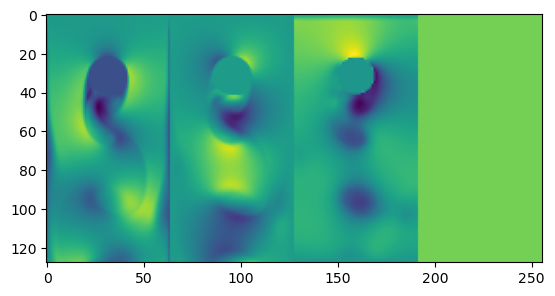

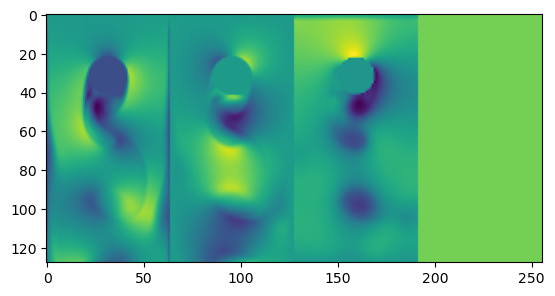

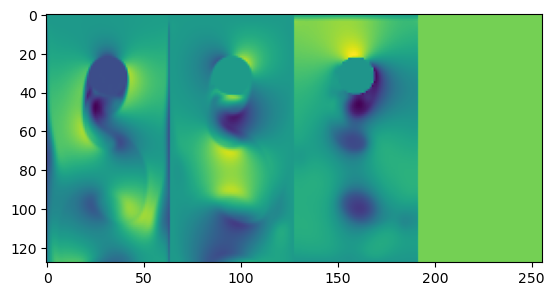

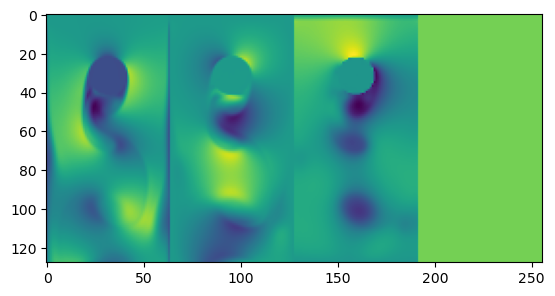

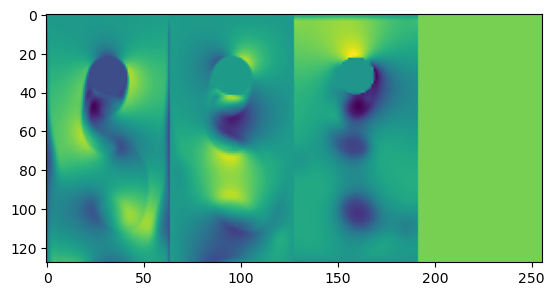

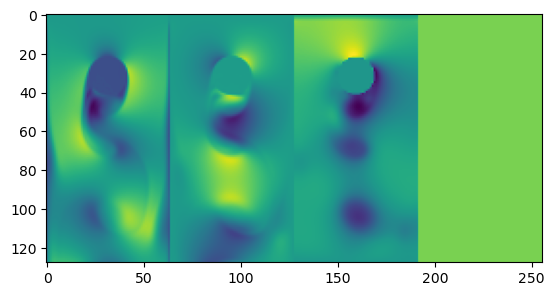

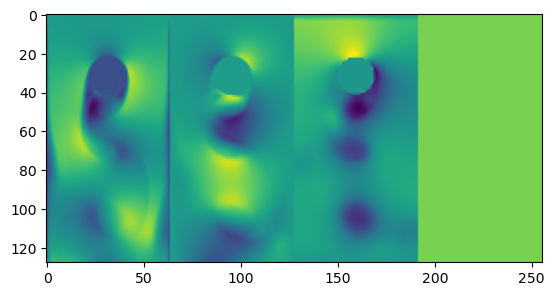

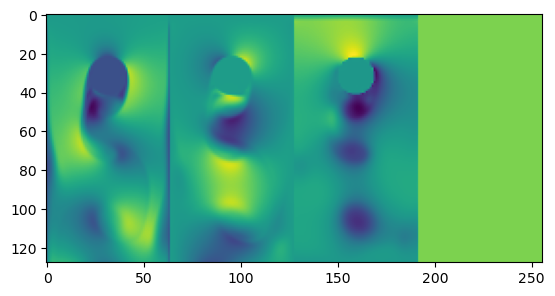

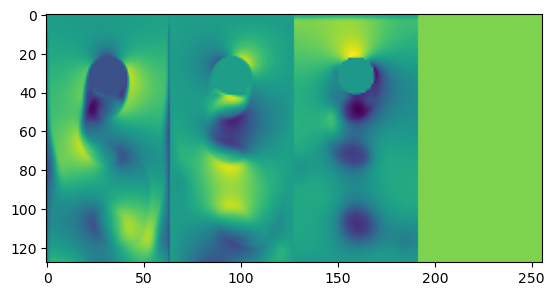

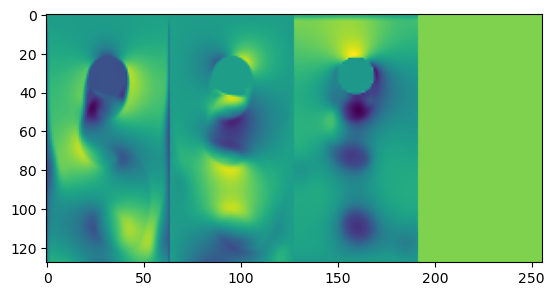

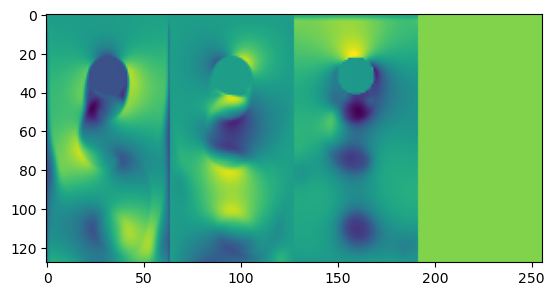

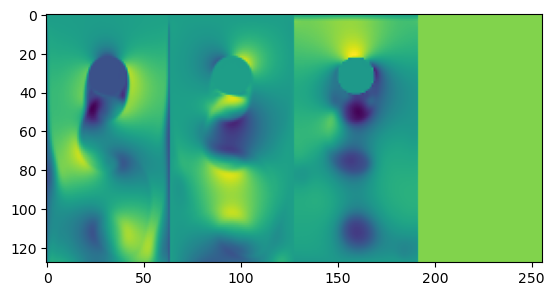

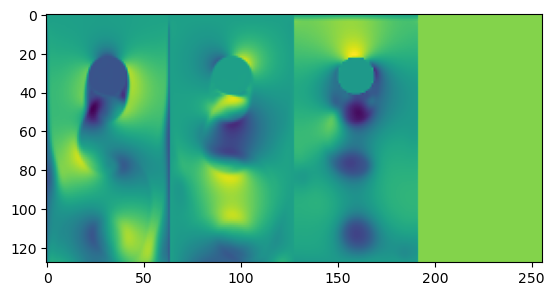

In [68]:
pred_idx = 0

for i in range(predSamples[0].shape[2]):
    # plt.imshow(rearrange(prediction[pred_idx, i, :, :, :].cpu().numpy(), 'c h w -> h (c w)'))
    plt.imshow(rearrange(predSamples[0][0, pred_idx, i, :, :, :], 'c h w -> h (c w)'))
    plt.show()